In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('Mall_Customers.csv')
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [5]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [6]:
df.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [7]:
df.duplicated().sum()

np.int64(0)

## Dataset Observations

- The dataset contains 200 customer records and 5 features.
- No missing values were found in any column.
- No duplicate records were found in the dataset.
- The average customer age is approximately 39 years.
- The average annual income is around 60.5k dollars.
- The average spending score is around 50.
- The dataset is clean and ready for exploratory data analysis and customer segmentation.

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

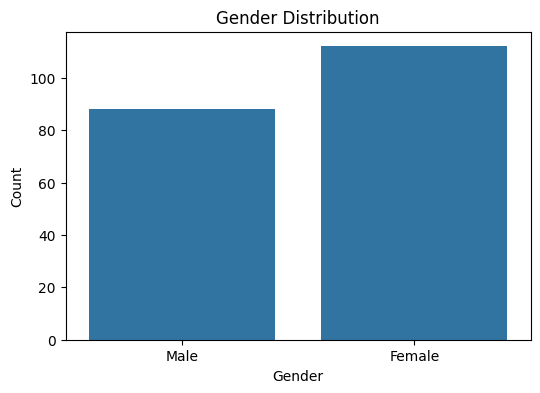

In [9]:
plt.figure(figsize=(6,4))
sns.countplot(x='Genre', data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.show()

## Gender Distribution Observation

- The dataset contains both male and female customers.
- Female customers are slightly more than male customers.
- The distribution is fairly balanced.

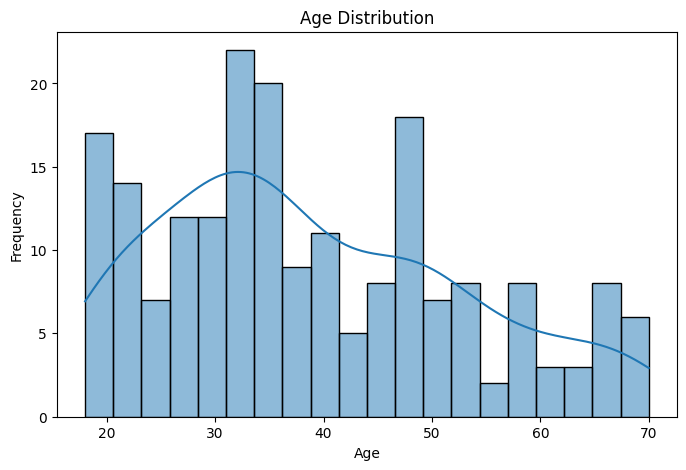

In [11]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

## Age Distribution Observation

- Most customers belong to the age group of 25–45 years.
- Very young and very old customers are fewer in number.
- The customer base is mainly composed of adults.

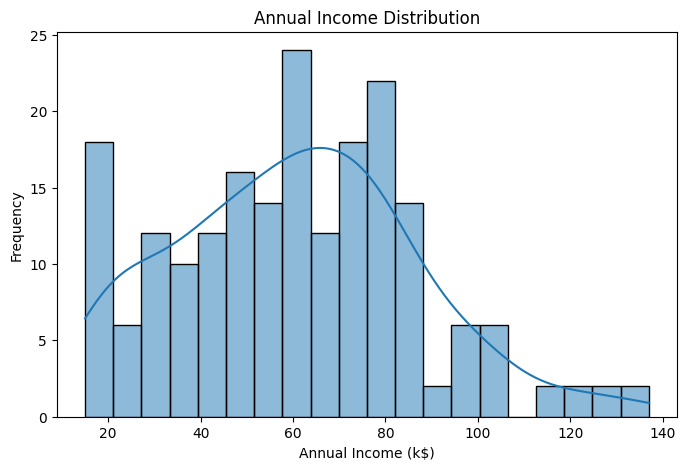

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(df['Annual Income (k$)'], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Frequency")

plt.show()

## Annual Income Observation

- Customer income ranges from low to high levels.
- Most customers fall within the middle-income range.
- The dataset contains customers from diverse income groups.

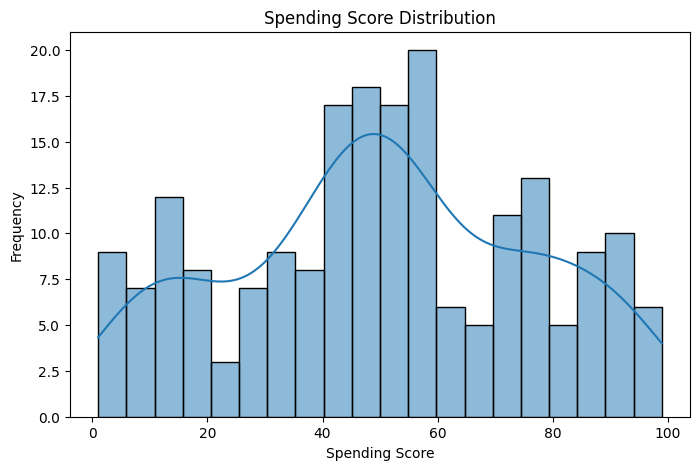

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df['Spending Score (1-100)'], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Frequency")

plt.show()

## Spending Score Observation

- Spending scores are distributed across a wide range.
- Customers exhibit different purchasing behaviors.
- Both low-spending and high-spending customers are present.

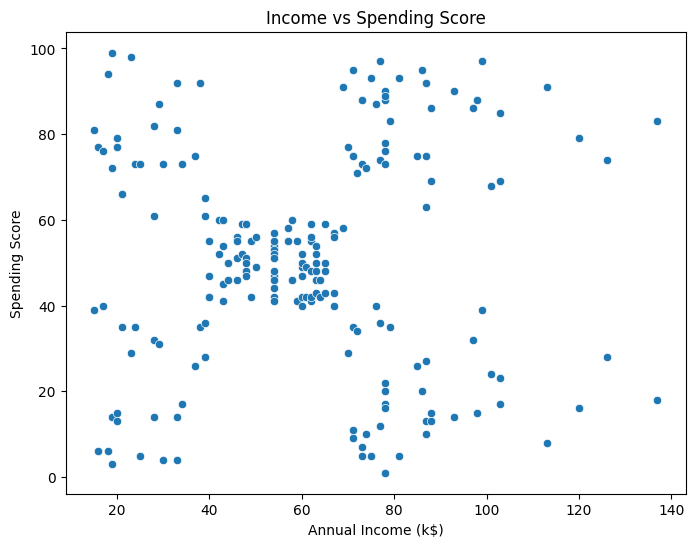

In [14]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    data=df
)

plt.title("Income vs Spending Score")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.show()

## Income vs Spending Score Observation

- A relationship can be observed between annual income and spending score.
- Some customers have high income and high spending behavior.
- Some customers have high income but low spending behavior.
- Different customer groups are visible in the scatter plot.
- These patterns indicate that customer segmentation can be effectively performed using clustering techniques.

In [15]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


In [16]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)

    wcss.append(kmeans.inertia_)

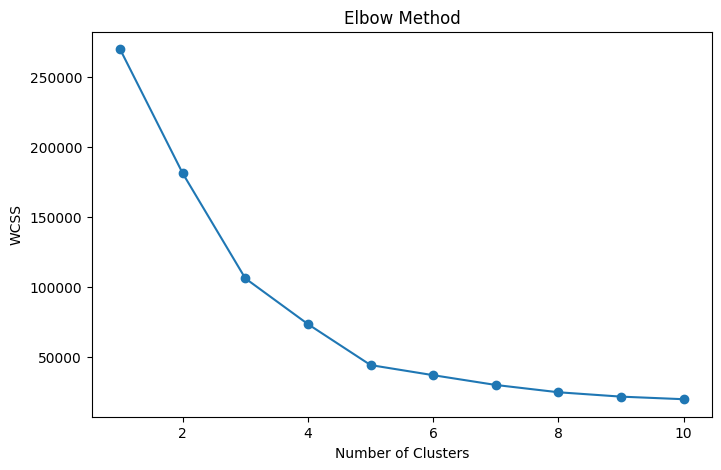

In [17]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

## Elbow Method Observation

- The Elbow Method was used to determine the optimal number of clusters.
- WCSS decreases significantly from 1 to 5 clusters.
- After 5 clusters, the rate of decrease becomes much slower.
- Therefore, 5 was selected as the optimal number of clusters for K-Means clustering.

In [24]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

y_kmeans = kmeans.fit_predict(X)

In [25]:
df['Cluster'] = y_kmeans

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


## Cluster Assignment Observation

- Customers were successfully assigned to 5 different clusters.
- Each cluster represents a unique customer segment.
- These segments are based on annual income and spending behavior.

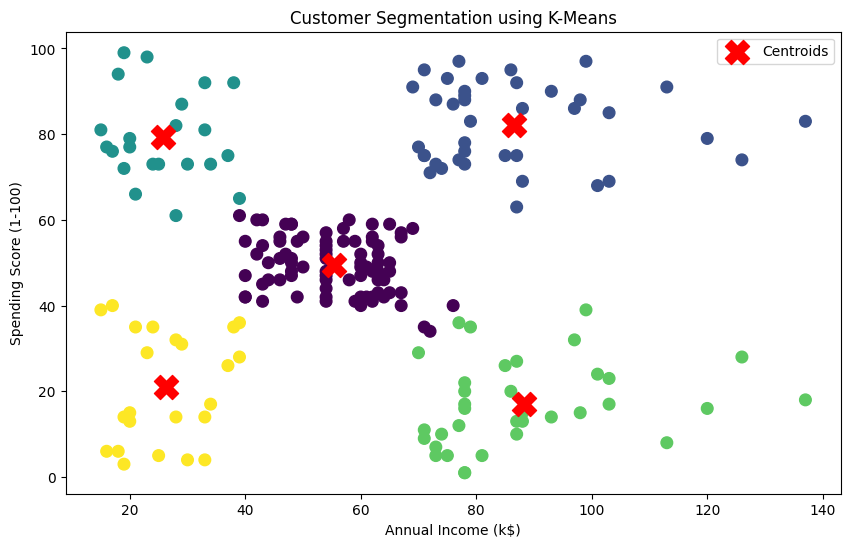

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y_kmeans,
    cmap='viridis',
    s=70
)

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.legend()

plt.show()

## Customer Segmentation Observation

- Customers were successfully divided into 5 distinct clusters.
- Each cluster represents a different spending and income pattern.
- Cluster centroids indicate the center point of each customer segment.
- The visualization clearly shows customer groups with similar purchasing behavior.
- K-Means clustering effectively identified meaningful customer segments.

In [27]:
df['Cluster'].value_counts()

,count
Cluster,
0,81
1,39
3,35
4,23
2,22


In [28]:
df.groupby('Cluster')[
    ['Annual Income (k$)', 'Spending Score (1-100)']
].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


## Cluster Analysis Observation

- Five distinct customer segments were identified using K-Means clustering.
- Each cluster shows different income and spending characteristics.
- Some customers have high income and high spending behavior.
- Some customers have high income but low spending behavior.
- A large group of customers belongs to the average income and average spending category.
- These segments can help businesses create targeted marketing strategies.

# Business Insights

### Premium Customers (Cluster 1)
- High income and high spending customers.
- Most valuable customer segment.
- Suitable for premium offers and loyalty programs.

### Careful Customers (Cluster 3)
- High income but low spending.
- Potential target for personalized marketing campaigns.

### Impulsive Customers (Cluster 2)
- Low income but high spending.
- Frequently purchase products despite lower income levels.

### Budget Customers (Cluster 4)
- Low income and low spending.
- Sensitive to discounts and promotional offers.

### Regular Customers (Cluster 0)
- Average income and average spending.
- Represent the largest customer group.
- Important for maintaining stable business revenue.

# Conclusion

In this project, customer segmentation was performed using the K-Means Clustering algorithm.

After analyzing customer income and spending behavior, five distinct customer groups were identified. These segments provide valuable business insights and can help organizations design targeted marketing strategies, improve customer engagement, and increase profitability.

The project demonstrates how machine learning techniques can be applied to solve real-world business problems.